In [1]:
import numpy as np
from types import SimpleNamespace
import jax
import jax.numpy as jnp
import optax
from flax import nnx
from jax import random
import time
#import matplotlib.pyplot as plt
import os
from tools import gauss_hermite

In [2]:
import flax
from flax.core import FrozenDict

print("Flax version:", flax.__version__)

Flax version: 0.12.1


In [3]:
for dev in jax.devices(): print(dev)

try: # choose gpu if avaliable
    device = jax.devices('gpu')[0]
except: # otherwise default to cpu
    device = jax.devices('cpu')[0]

device

TFRT_CPU_0


CpuDevice(id=0)

In [4]:
par = SimpleNamespace()

par.phi = 1.1
par.sigma = 2.0
par.beta = 0.95
par.kappa = 0.2
par.mu = 1.0
par.sigma_eps_i = 0.001
par.Gamma = 1.0
par.varphi = 1.0
par.rho_i = 0.9

def marg_util(par, C):
    return C**(-par.sigma)

In [5]:
def compute_DSS(par, return_DSS=False):

    # closed form
    pi = 0.0
    i = 1/par.beta - 1
    Y = (par.Gamma**((1+par.varphi)/(par.sigma+par.varphi)))/(par.mu**(1/(par.sigma+par.varphi)))

    # evaluate DSS equations
    taylor_error = i - i - par.phi*pi
    euler_error = marg_util(par, Y)-par.beta*( (1+i)/(1+pi) )*marg_util(par,Y)
    NKPC_error = pi*(1+pi)-par.kappa*( (Y**(par.sigma+par.varphi))/(par.Gamma**(1+par.varphi))-1/par.mu) - (Y/Y)*((1+i)/(1+pi)) * pi*(1+pi)

    print(f'Taylor rule error:\t\t{taylor_error:.4f}')
    print(f'Euler Equation error:\t\t{euler_error:.4f}')
    print(f'NKPC error:\t\t\t{NKPC_error:.4f}')

    if return_DSS:
        return SimpleNamespace(pi = pi, i = i, Y = Y)

    else:
        return Y, pi, i

In [6]:
DSS = compute_DSS(par, return_DSS=True)

Taylor rule error:		0.0000
Euler Equation error:		0.0000
NKPC error:			0.0000


## Neural nets

In [7]:
train = SimpleNamespace()
train.T = 50
train.Nstates = 2
train.neurons = [50, 50, 50]
train.Nparallel = 100
train.simT = 5
train.lr = 1e-4

nodes, weights = gauss_hermite(10)

train.gh_nodes = np.sqrt(2)*par.sigma_eps_i*nodes
train.gh_weights = weights/np.sqrt(np.pi)

DSS_dict = DSS.__dict__
par_dict = par.__dict__
train_dict = train.__dict__

class model: pass

model.par = par_dict
model.train = train_dict
model.DSS = DSS_dict

In [8]:
class Policy(nnx.Module):

  # layers should be flax compatible list: syntax for parameter updates in list
  layers: list[nnx.Linear]
  
  def __init__(self, din: int, dout: int, neurons: list, rngs: nnx.Rngs):

    # 1. initialize
    layers = []

    # 2. 1st layer
    layers.append(nnx.Linear(din, neurons[0], rngs=rngs))
    
    # 3. hidden layers
    for layer in range(len(neurons)-1):
      
      layers.append(nnx.Linear(neurons[layer], neurons[layer+1], rngs=rngs))

    # 4. output layer
    layers.append(nnx.Linear(neurons[-1], dout, rngs=rngs))

    # 5. assign to neural network
    self.layers = nnx.List(layers)

  def __call__(self, x: jax.Array):

    # 1. 1st and hiden layers
    for layer in self.layers[:-1]:

      x = nnx.gelu(layer(x)) # ReLU activation for input and all hidden layers

    # 2. output layer
    z = self.layers[-1](x) 

    z1, z2 = jnp.split(z, 2, axis=-1)

    Y = nnx.softplus(z1) # [0,infty]
    pi = nnx.softplus(z2) - 1 # shifted softplus -> [-1,infty]

    out = jnp.concatenate([Y,pi], axis=-1)
    
    return out
  
hidden_layers = [5,5,10] # 5 neurons in input and first hidden layer and 10 in second hidden layer
din = 10 # number of states and time periods
dout = 2 # number of actionspip

neural_net_test = Policy(din, dout, hidden_layers, rngs=nnx.Rngs(params=0))

x_test = jnp.zeros((1,din)) # = random.normal(random.key(0), shape=(1,din))

neural_net_test(x_test)

Array([[ 0.6931472 , -0.30685282]], dtype=float32)

In [9]:
def setup_nn(model):
  """
  Function that takes economic model object and returns suitable neural network
  """

  train = model.train

  # 1. compute in- and output dimensions and retrieve list of neurons
  din = train.get("T")
  dout = train.get("Nstates")
  neurons = train.get("neurons")

  # 2. call policy class
  nn = Policy(din, dout, neurons, rngs=nnx.Rngs(params=0)) # last kwarg set seed=0 for bias and weight initialization

  # 3. setup optimizer
  opt = nnx.ModelAndOptimizer(nn, optax.adam(learning_rate=train.get("lr")))

  # 4. save in model
  model.nn = nn
  model.opt = opt

In [10]:
def draw_shocks(model):

    train = model.train
    par = model.par

    Nparallel = train.get("Nparallel")
    sigma_eps_i = par.get("sigma_eps_i")

    eps_i = np.random.normal(0, sigma_eps_i, size=(Nparallel,))

    return eps_i

In [11]:
setup_nn(model)

## Training the neural network to the DSS and SSS

## The economy

In [12]:
def taylor_rule(model, pi, pi_p, u_i):
    
    par = model.par
    DSS = model.DSS

    phi = par.get("phi")
    i_DSS = DSS.get("i")

    i = i_DSS+phi*pi+u_i # (Nparallel)
    r_p = (1+i[:,None])/(1+pi_p) # (Nparallel,weights)

    return r_p

def euler_error(model, Y, Y_p, pi, pi_p, u_i, weights):

    # Y,pi is (Nparallel,)
    # Y_p,pi_p is (Nparallel,weigths)

    par = model.par

    beta = par.get("beta")
    sigma = par.get("sigma")

    # taylor rule
    r_p = taylor_rule(model, pi, pi_p, u_i)

    # period t
    MU = Y**(-sigma) # (Nparallel)

    # period t+1
    MU_p = beta*r_p*Y_p**(-sigma) # (Nparallel,weights)
    EMU_p = jnp.sum(weights*MU_p, axis=-1) # (Nparallel,)

    return MU-EMU_p

def NKPC_error(model, pi, pi_p, Y, Y_p, u_i, weights):

    # Y is (Nparallel,)
    # Y_p,r_p is (Nparallel,weigths)
    
    par = model.par

    kappa = par.get("kappa")
    mu = par.get("mu")
    sigma = par.get("sigma")
    varphi = par.get("varphi")
    Gamma = par.get("Gamma")

    # taylor rule
    r_p = taylor_rule(model, pi, pi_p, u_i)

    # NKPC terms
    frac = (Y*((sigma+varphi)/(1+varphi)))/(Gamma**(1+varphi))
    today = pi*(1-pi)-kappa*( frac - 1/mu) # (Nparallel,)
    tomorrow = ((Y_p/Y[:,None])*(1/(1+r_p)))*pi_p*(1-pi_p) # (Nparallel,weights)
    Etomorrow = jnp.sum(weights*tomorrow, axis=-1) # (Nparallel,)

    return today - Etomorrow

In [13]:
def next_eps_hist_quad(eps_hist, quad): 
    
    # eps_hist is (Nparallel,T)
    Nparallel = eps_hist.shape[0]
    Nquad = len(quad)

    eps_hist_repeated = eps_hist[:,1:].repeat(Nquad,axis=0)
    quad_tiled = jnp.tile(quad, Nparallel)

    return jnp.concatenate((eps_hist_repeated, quad_tiled.reshape(-1,1)), axis=1)

def next_eps_hist(eps_hist, eps):

    eps_hist_truncated = eps_hist[:,1:]
    
    return jnp.concatenate((eps_hist_truncated, eps.reshape(-1,1)), axis=1)

def next_u_i(model, eps_i, u_i):

    par = model.par

    rho_i = par.get("rho_i")

    u_i_p = rho_i*u_i + eps_i

    return u_i_p  

In [14]:
def train_SS(model, DSS_episodes=1000, SSS_episodes=1000, start_nonzero_shocks=200, tol=1e-10):

    # 1. unpack
    train = model.train
    nn = model.nn
    opt = model.opt

    Nparallel = train.get("Nparallel")
    T = train.get("T")

    # 2. initialize zero shocks
    zero_shocks = jnp.zeros((Nparallel,T))

    # 3. DSS training
    print('Beginning DSS training')
    for k in range(DSS_episodes):

        if k >= start_nonzero_shocks: zero_shocks = np.random.normal(0, 0.001, size=(Nparallel,T))

        loss_fn = lambda nn: DSS_loss(nn, model, zero_shocks)
        loss, grad = jax.value_and_grad(loss_fn)(nn)
        
        if k % 10 == 0: print(f'Episode {k}: Loss = {loss:.8f}')
        opt.update(grad)

        #if loss<tol:
        #    
        #    print('No improvement, stopping training')
        #    break
    
    # 4. unpack for SSS training and initialize new zero shocks
    gh_weights = train.get("gh_weights")
    gh_nodes = train.get("gh_nodes")
    
    zero_shocks = jnp.zeros((Nparallel,T))

    # 5. SSS training
    print('Beginning SSS training')
    for k in range(SSS_episodes):

        if k >= start_nonzero_shocks: zero_shocks = np.random.normal(0, 0.001, size=(Nparallel,T))

        loss_fn = lambda nn: SSS_loss(nn, model, zero_shocks, gh_nodes, gh_weights, Nparallel)
        
        loss, grad = jax.value_and_grad(loss_fn)(nn)
        
        if k % 10 == 0: print(f'Episode {k}: Loss = {loss:.8f}')
        opt.update(grad)

        if loss<tol:
            print('No improvement, stopping training')
            break

def DSS_loss(nn, model, zero_shocks):

    DSS = model.DSS

    # 1. call nn
    out = nn(zero_shocks)
    Y = out[:,0]
    pi = out[:,1]

    # 2. compute mse
    Y_errors = (Y - DSS.get("Y"))**2
    pi_errors = (pi - DSS.get("pi"))**2
    loss = jnp.mean(Y_errors) + jnp.mean(pi_errors)
    
    return loss

def SSS_loss(nn, model, zero_shocks, gh_nodes, gh_weights, Nparallel):

    # 1. call nn
    out = nn(zero_shocks)
    Y = out[:,0]
    pi = out[:,1]

    # 2. call next-period nn on quadrature nodes and unpack MP-shock
    zero_shocks_quad = next_eps_hist_quad(zero_shocks, gh_nodes)
    out_p = nn(zero_shocks_quad).reshape(Nparallel,-1,2)
    Y_p = out_p[...,0]
    pi_p = out_p[...,1]
    zero_u_i = zero_shocks[:,-1]

    # 3. compute equilibrium errors
    Y_errors = euler_error(model, Y, Y_p, pi, pi_p, zero_u_i, gh_weights)
    pi_errors = NKPC_error(model, pi, pi_p, Y, Y_p, zero_u_i, gh_weights)

    # 4. compute mse
    loss = jnp.mean(Y_errors**2) + jnp.mean(pi_errors**2)
    
    return loss

train_SS(model, SSS_episodes=1000)

Beginning DSS training
Episode 0: Loss = 0.18831730
Episode 10: Loss = 0.18553892
Episode 20: Loss = 0.18258318
Episode 30: Loss = 0.17939202
Episode 40: Loss = 0.17590910
Episode 50: Loss = 0.17208071
Episode 60: Loss = 0.16785574
Episode 70: Loss = 0.16318604
Episode 80: Loss = 0.15802599
Episode 90: Loss = 0.15233412
Episode 100: Loss = 0.14607449
Episode 110: Loss = 0.13921875
Episode 120: Loss = 0.13174963
Episode 130: Loss = 0.12366416
Episode 140: Loss = 0.11497846
Episode 150: Loss = 0.10573211
Episode 160: Loss = 0.09599356
Episode 170: Loss = 0.08586422
Episode 180: Loss = 0.07548323
Episode 190: Loss = 0.06503023
Episode 200: Loss = 0.05473962
Episode 210: Loss = 0.04480635
Episode 220: Loss = 0.03560150
Episode 230: Loss = 0.02729214
Episode 240: Loss = 0.02007698
Episode 250: Loss = 0.01421307
Episode 260: Loss = 0.00963862
Episode 270: Loss = 0.00623826
Episode 280: Loss = 0.00388834
Episode 290: Loss = 0.00234428
Episode 300: Loss = 0.00136973
Episode 310: Loss = 0.00078

In [15]:
model.nn(jnp.zeros(50))

Array([0.9099386 , 0.16882789], dtype=float32)

In [16]:
def full_loss_fn(nn, model, eps_hist, u_i):

    train = model.train

    gh_nodes = train.get("gh_nodes")
    gh_weights = train.get("gh_weights")
    Nparallel = train.get("Nparallel")

    # a. evaluate nn in MA-history + compute MP-shock -> state space in period t
    out = nn(eps_hist)
    Y = out[:,0]
    pi = out[:,1]
    eps_i = eps_hist[:,-1]
    u_i = next_u_i(model, eps_i, u_i)

    # b. evaluate nn in MA-history with quadrature as latest shock, no need for MP-shock in next period -> state space in period t+1
    eps_hist_quad = next_eps_hist_quad(eps_hist, gh_nodes)
    out_p = nn(eps_hist_quad).reshape(Nparallel,-1,2)
    Y_p = out_p[...,0]
    pi_p = out_p[...,1]
    
    # c. evaluate equilibrium equations
    Y_errors = euler_error(model, Y, Y_p, pi, pi_p, u_i, gh_weights)
    pi_errors = NKPC_error(model, pi, pi_p, Y, Y_p, u_i, gh_weights)

    # d. compute loss
    loss = jnp.mean(Y_errors**2) + jnp.mean(pi_errors**2)
    
    return loss

def aux_loss_fn(nn, model, eps_hist, u_i):

    train = model.train

    gh_nodes = train.get("gh_nodes")
    gh_weights = train.get("gh_weights")
    Nparallel = train.get("Nparallel")

    # a. evaluate nn in MA-history + compute MP-shock -> state space in period t
    out = nn(eps_hist)
    Y = out[:,0]
    pi = out[:,1]
    eps_i = eps_hist[:,-1]
    u_i = next_u_i(model, eps_i, u_i)

    # b. evaluate nn in MA-history with quadrature as latest shock, no need for MP-shock in next period -> state space in period t+1
    eps_hist_quad = next_eps_hist_quad(eps_hist, gh_nodes)
    out_p = nn(eps_hist_quad).reshape(Nparallel,-1,2)
    Y_p = out_p[...,0]
    pi_p = out_p[...,1]
    
    # c. evaluate equilibrium equations
    Y_errors = euler_error(model, Y, Y_p, pi, pi_p, u_i, gh_weights)
    pi_errors = NKPC_error(model, pi, pi_p, Y, Y_p, u_i, gh_weights)

    # d. compute loss

    return jnp.mean(Y_errors), jnp.mean(pi_errors)

def train_nn(model, episodes):

    train = model.train
    nn = model.nn
    opt = model.opt

    Nparallel = train.get("Nparallel")
    T = train.get("T")

    eps_hist = jnp.zeros((Nparallel,T))
    u_i = jnp.zeros((Nparallel,))
    
    best_loss = 1e8
    for k in range(episodes):

        loss_fn = lambda nn: full_loss_fn(nn, model, eps_hist, u_i)
        
        loss, grad = jax.value_and_grad(loss_fn)(nn)
        
        if (loss < best_loss and k>10): best_loss = loss
        if k % 10 == 0:
            out = nn(jnp.zeros(T))
            Y_SSS = out[0]
            pi_SSS = out[1]
            Y_errors, pi_errors = aux_loss_fn(nn, model, eps_hist, u_i)
            print(f'Episode {k}:\tLoss = {loss:.8f}\tBest Loss = {best_loss:.8f}\t\tSSS: Y = {Y_SSS:.3f}, pi_SSS = {pi_SSS:.3f}\t\tErrors: Y = {Y_errors:.8f}, pi = {pi_errors:.8f}')
        
        opt.update(grad)
        
        eps = draw_shocks(model)
        eps_hist = next_eps_hist(eps_hist,eps)
        u_i = next_u_i(model, eps, u_i)

    return nn

In [18]:
trained_nn = train_nn(model, 100000)

Episode 0:	Loss = 0.00005652	Best Loss = 100000000.00000000		SSS: Y = 0.889, pi_SSS = 0.151		Errors: Y = -0.00747514, pi = -0.00080441
Episode 10:	Loss = 0.00006366	Best Loss = 100000000.00000000		SSS: Y = 0.889, pi_SSS = 0.151		Errors: Y = -0.00778192, pi = -0.00079053
Episode 20:	Loss = 0.00005935	Best Loss = 0.00005935		SSS: Y = 0.889, pi_SSS = 0.151		Errors: Y = -0.00747601, pi = -0.00076518
Episode 30:	Loss = 0.00006212	Best Loss = 0.00005935		SSS: Y = 0.889, pi_SSS = 0.151		Errors: Y = -0.00761921, pi = -0.00084896
Episode 40:	Loss = 0.00005920	Best Loss = 0.00005849		SSS: Y = 0.889, pi_SSS = 0.151		Errors: Y = -0.00741357, pi = -0.00084732
Episode 50:	Loss = 0.00006199	Best Loss = 0.00005849		SSS: Y = 0.888, pi_SSS = 0.150		Errors: Y = -0.00762391, pi = -0.00076405
Episode 60:	Loss = 0.00005744	Best Loss = 0.00005744		SSS: Y = 0.888, pi_SSS = 0.150		Errors: Y = -0.00732714, pi = -0.00072617
Episode 70:	Loss = 0.00005692	Best Loss = 0.00005411		SSS: Y = 0.888, pi_SSS = 0.150		Err

KeyboardInterrupt: 

In [46]:
out_SSS = model.nn(jnp.zeros(50))
Y_SSS = out_SSS[0]
pi_SSS = out_SSS[1]


IRF = jnp.zeros((50,2)) + jnp.nan

for t in range(model.train.get("T")):
    shock = jnp.zeros(50)
    shock = shock.at[-t].set(0.01)
    out = model.nn(shock)
    Y_t = out[0]
    pi_t = out[1]
    Y_IRF = (Y_t - Y_SSS)/Y_SSS
    pi_IRF = pi_t - pi_SSS

    IRF = IRF.at[t,0].set(Y_IRF)
    IRF = IRF.at[t,1].set(pi_IRF)

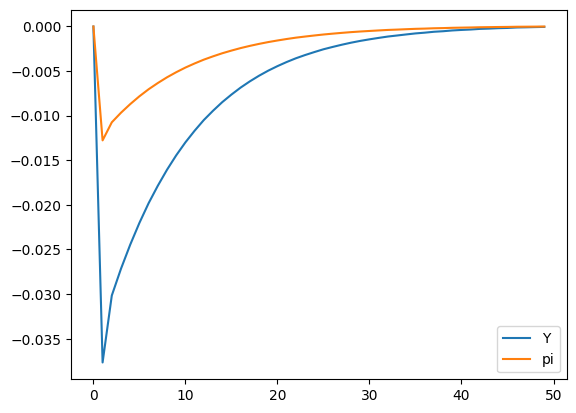

In [47]:
import matplotlib.pyplot as plt
plt.plot(IRF[:,0], label='Y')
plt.plot(IRF[:,1], label='pi')
plt.legend()